# Water Flow Tile Test - Rust/Evcxr

Rust version of the Python notebook's import and visualization setup. This stops after loading the default PMTiles tile, extracting the `water` and `waterway` layers, and rendering them into an inline PNG.

Kernel setup, if the Rust kernel is not listed in Jupyter yet:

```powershell
cargo install evcxr_jupyter
evcxr_jupyter --install
```


In [2]:
:dep anyhow = "1.0"
:dep base64 = "0.22"
:dep geo-types = { version = "0.7", default-features = false }
:dep image = { version = "0.25", default-features = false, features = ["png"] }
:dep mvt-reader = "=2.3.0"
:dep pmtiles = { version = "=0.23.0", default-features = false, features = ["mmap-async-tokio"] }
:dep tokio = { version = "1", features = ["rt-multi-thread"] }


In [3]:
use anyhow::{bail, Context, Result};
use base64::{engine::general_purpose, Engine as _};
use geo_types::{Coord, Geometry, LineString, Polygon};
use image::{imageops::FilterType, DynamicImage, ImageFormat, Rgba, RgbaImage};
use mvt_reader::Reader as MvtReader;
use std::cmp::Ordering;
use std::io::Cursor;
use std::path::{Path, PathBuf};

const DEFAULT_TILE: (u8, u32, u32) = (14, 8798, 5373);
const DEFAULT_WATER_LAYER: &str = "water";
const DEFAULT_WATERWAY_LAYER: &str = "waterway";
const DEFAULT_IMAGE_SIZE: u32 = 512;
const DEFAULT_TILE_EXTENT: u32 = 4096;


In [4]:
#[derive(Clone, Debug)]
struct LayerSummary {
    layer: String,
    extent: u32,
    features: usize,
}

#[derive(Clone, Debug)]
struct TileWaterData {
    layer_summary: Vec<LayerSummary>,
    water_geometries: Vec<Geometry<f64>>,
    waterway_geometries: Vec<Geometry<f64>>,
    extent: u32,
}

fn find_repo_root(start: Option<&Path>) -> Result<PathBuf> {
    let mut current = match start {
        Some(path) => path.to_path_buf(),
        None => std::env::current_dir().context("failed to read current directory")?,
    };

    if current.is_file() {
        current.pop();
    }

    loop {
        if current.join("jupyter").join("data").is_dir() {
            return Ok(current);
        }
        if !current.pop() {
            bail!("could not find repo root containing jupyter/data");
        }
    }
}

fn default_pmtiles_path() -> Result<PathBuf> {
    Ok(find_repo_root(None)?.join("jupyter").join("data").join("berlin.pmtiles"))
}

fn extract_tile(pmtiles_path: &Path, z: u8, x: u32, y: u32) -> Result<TileWaterData> {
    let runtime = tokio::runtime::Runtime::new().context("failed to create Tokio runtime")?;
    let tile_bytes = runtime.block_on(async {
        let reader = pmtiles::AsyncPmTilesReader::new_with_path(pmtiles_path)
            .await
            .with_context(|| format!("failed to open {}", pmtiles_path.display()))?;
        let coord = pmtiles::TileCoord::new(z, x, y)?;
        let Some(tile_bytes) = reader.get_tile_decompressed(coord).await? else {
            bail!("tile {z}/{x}/{y} was not found in {}", pmtiles_path.display());
        };
        Ok::<Vec<u8>, anyhow::Error>(tile_bytes.to_vec())
    })?;

    let reader = MvtReader::new(tile_bytes)
        .map_err(|err| anyhow::anyhow!("failed to decode MVT tile: {err}"))?;
    let layers = reader
        .get_layer_metadata()
        .map_err(|err| anyhow::anyhow!("failed to read MVT layer metadata: {err}"))?;

    let mut layer_summary = Vec::with_capacity(layers.len());
    let mut water_geometries = Vec::new();
    let mut waterway_geometries = Vec::new();
    let mut water_extent = None;
    let mut waterway_extent = None;

    for layer in layers {
        layer_summary.push(LayerSummary {
            layer: layer.name.clone(),
            extent: layer.extent,
            features: layer.feature_count,
        });

        if layer.name == DEFAULT_WATER_LAYER || layer.name == DEFAULT_WATERWAY_LAYER {
            let features = reader
                .get_features_as::<f64>(layer.layer_index)
                .map_err(|err| anyhow::anyhow!("failed to read layer {}: {err}", layer.name))?;

            if layer.name == DEFAULT_WATER_LAYER {
                water_extent = Some(layer.extent);
                water_geometries.extend(features.into_iter().map(|feature| feature.geometry));
            } else {
                waterway_extent = Some(layer.extent);
                waterway_geometries.extend(features.into_iter().map(|feature| feature.geometry));
            }
        }
    }

    layer_summary.sort_by(|a, b| a.layer.cmp(&b.layer));
    let extent = water_extent.or(waterway_extent).unwrap_or(DEFAULT_TILE_EXTENT);

    Ok(TileWaterData {
        layer_summary,
        water_geometries,
        waterway_geometries,
        extent,
    })
}


In [5]:
fn render_water_geometries(
    data: &TileWaterData,
    image_size: u32,
    antialias_scale: u32,
) -> Result<Vec<u8>> {
    let scale = antialias_scale.max(1);
    let render_size = image_size * scale;
    let background = Rgba([250, 249, 245, 255]);
    let mut image = RgbaImage::from_pixel(render_size, render_size, background);

    for (index, geometry) in data.water_geometries.iter().enumerate() {
        let fill = polygon_color(index);
        let outline = darken(fill, 0.55);
        draw_polygon_geometry(
            &mut image,
            geometry,
            f64::from(data.extent),
            render_size,
            fill,
            outline,
            background,
            scale,
        );
    }

    for geometry in &data.waterway_geometries {
        draw_line_geometry(
            &mut image,
            geometry,
            f64::from(data.extent),
            render_size,
            Rgba([255, 86, 51, 255]),
            Rgba([50, 44, 38, 220]),
            (scale * 2).max(2),
        );
    }

    let resized = DynamicImage::ImageRgba8(image)
        .resize_exact(image_size, image_size, FilterType::Lanczos3)
        .to_rgba8();
    let mut output = Cursor::new(Vec::new());
    DynamicImage::ImageRgba8(resized).write_to(&mut output, ImageFormat::Png)?;
    Ok(output.into_inner())
}

fn display_png(png: &[u8]) {
    let encoded = general_purpose::STANDARD.encode(png);
    println!("EVCXR_BEGIN_CONTENT image/png
{}
EVCXR_END_CONTENT", encoded);
}

fn polygon_color(index: usize) -> Rgba<u8> {
    let mut seed = 10_000_u64 + index as u64;
    Rgba([
        next_range(&mut seed, 54, 110),
        next_range(&mut seed, 130, 205),
        next_range(&mut seed, 175, 235),
        185,
    ])
}

fn next_range(seed: &mut u64, min: u8, max: u8) -> u8 {
    *seed = seed.wrapping_mul(1_664_525).wrapping_add(1_013_904_223);
    let span = u64::from(max - min + 1);
    min + ((*seed >> 16) % span) as u8
}

fn darken(color: Rgba<u8>, factor: f32) -> Rgba<u8> {
    Rgba([
        (f32::from(color[0]) * factor).round() as u8,
        (f32::from(color[1]) * factor).round() as u8,
        (f32::from(color[2]) * factor).round() as u8,
        255,
    ])
}

fn draw_polygon_geometry(
    image: &mut RgbaImage,
    geometry: &Geometry<f64>,
    extent: f64,
    image_size: u32,
    fill: Rgba<u8>,
    outline: Rgba<u8>,
    background: Rgba<u8>,
    outline_width: u32,
) {
    match geometry {
        Geometry::Polygon(polygon) => draw_polygon(image, polygon, extent, image_size, fill, outline, background, outline_width),
        Geometry::MultiPolygon(multi_polygon) => {
            for polygon in &multi_polygon.0 {
                draw_polygon(image, polygon, extent, image_size, fill, outline, background, outline_width);
            }
        }
        Geometry::GeometryCollection(collection) => {
            for child in &collection.0 {
                draw_polygon_geometry(image, child, extent, image_size, fill, outline, background, outline_width);
            }
        }
        _ => {}
    }
}

fn draw_polygon(
    image: &mut RgbaImage,
    polygon: &Polygon<f64>,
    extent: f64,
    image_size: u32,
    fill: Rgba<u8>,
    outline: Rgba<u8>,
    background: Rgba<u8>,
    outline_width: u32,
) {
    let exterior = line_string_to_pixels(polygon.exterior(), extent, image_size);
    if exterior.len() >= 3 {
        fill_polygon(image, &exterior, fill);
        stroke_closed_polyline(image, &exterior, outline, outline_width);
    }

    for interior in polygon.interiors() {
        let hole = line_string_to_pixels(interior, extent, image_size);
        if hole.len() >= 3 {
            fill_polygon(image, &hole, background);
            stroke_closed_polyline(image, &hole, outline, outline_width);
        }
    }
}

fn draw_line_geometry(
    image: &mut RgbaImage,
    geometry: &Geometry<f64>,
    extent: f64,
    image_size: u32,
    fill: Rgba<u8>,
    casing: Rgba<u8>,
    width: u32,
) {
    match geometry {
        Geometry::Line(line) => {
            let a = coord_to_pixel(line.start, extent, image_size);
            let b = coord_to_pixel(line.end, extent, image_size);
            draw_thick_segment(image, a, b, casing, width + 2);
            draw_thick_segment(image, a, b, fill, width);
        }
        Geometry::LineString(line_string) => draw_line_string(image, line_string, extent, image_size, fill, casing, width),
        Geometry::MultiLineString(multi_line_string) => {
            for line_string in &multi_line_string.0 {
                draw_line_string(image, line_string, extent, image_size, fill, casing, width);
            }
        }
        Geometry::GeometryCollection(collection) => {
            for child in &collection.0 {
                draw_line_geometry(image, child, extent, image_size, fill, casing, width);
            }
        }
        _ => {}
    }
}

fn draw_line_string(
    image: &mut RgbaImage,
    line_string: &LineString<f64>,
    extent: f64,
    image_size: u32,
    fill: Rgba<u8>,
    casing: Rgba<u8>,
    width: u32,
) {
    let points = line_string_to_pixels(line_string, extent, image_size);
    for pair in points.windows(2) {
        draw_thick_segment(image, pair[0], pair[1], casing, width + 2);
        draw_thick_segment(image, pair[0], pair[1], fill, width);
    }
}

fn line_string_to_pixels(line_string: &LineString<f64>, extent: f64, image_size: u32) -> Vec<(f64, f64)> {
    line_string
        .0
        .iter()
        .map(|coord| coord_to_pixel(*coord, extent, image_size))
        .collect()
}

fn coord_to_pixel(coord: Coord<f64>, extent: f64, image_size: u32) -> (f64, f64) {
    (
        coord.x / extent * f64::from(image_size),
        coord.y / extent * f64::from(image_size),
    )
}

fn fill_polygon(image: &mut RgbaImage, points: &[(f64, f64)], color: Rgba<u8>) {
    if points.len() < 3 {
        return;
    }

    let min_y = points
        .iter()
        .map(|point| point.1)
        .fold(f64::INFINITY, f64::min)
        .floor()
        .max(0.0) as i32;
    let max_y = points
        .iter()
        .map(|point| point.1)
        .fold(f64::NEG_INFINITY, f64::max)
        .ceil()
        .min(f64::from(image.height().saturating_sub(1))) as i32;

    if min_y > max_y {
        return;
    }

    let mut intersections = Vec::new();
    for y in min_y..=max_y {
        let scan_y = f64::from(y) + 0.5;
        intersections.clear();

        for index in 0..points.len() {
            let (x1, y1) = points[index];
            let (x2, y2) = points[(index + 1) % points.len()];
            if (y1 <= scan_y && y2 > scan_y) || (y2 <= scan_y && y1 > scan_y) {
                let t = (scan_y - y1) / (y2 - y1);
                intersections.push(x1 + t * (x2 - x1));
            }
        }

        intersections.sort_by(|a, b| a.partial_cmp(b).unwrap_or(Ordering::Equal));
        for pair in intersections.chunks_exact(2) {
            let start = (pair[0] - 0.5).ceil().max(0.0) as i32;
            let end = (pair[1] - 0.5)
                .floor()
                .min(f64::from(image.width().saturating_sub(1))) as i32;
            for x in start..=end {
                blend_pixel(image, x, y, color);
            }
        }
    }
}

fn stroke_closed_polyline(image: &mut RgbaImage, points: &[(f64, f64)], color: Rgba<u8>, width: u32) {
    for pair in points.windows(2) {
        draw_thick_segment(image, pair[0], pair[1], color, width);
    }
    if let (Some(first), Some(last)) = (points.first(), points.last()) {
        draw_thick_segment(image, *last, *first, color, width);
    }
}

fn draw_thick_segment(
    image: &mut RgbaImage,
    a: (f64, f64),
    b: (f64, f64),
    color: Rgba<u8>,
    width: u32,
) {
    let radius = (f64::from(width.max(1)) * 0.5).max(0.5);
    let min_x = (a.0.min(b.0) - radius).floor().max(0.0) as i32;
    let max_x = (a.0.max(b.0) + radius)
        .ceil()
        .min(f64::from(image.width().saturating_sub(1))) as i32;
    let min_y = (a.1.min(b.1) - radius).floor().max(0.0) as i32;
    let max_y = (a.1.max(b.1) + radius)
        .ceil()
        .min(f64::from(image.height().saturating_sub(1))) as i32;

    let dx = b.0 - a.0;
    let dy = b.1 - a.1;
    let len_sq = dx * dx + dy * dy;
    let radius_sq = radius * radius;

    for y in min_y..=max_y {
        for x in min_x..=max_x {
            let px = f64::from(x) + 0.5;
            let py = f64::from(y) + 0.5;
            let distance_sq = if len_sq <= f64::EPSILON {
                let ox = px - a.0;
                let oy = py - a.1;
                ox * ox + oy * oy
            } else {
                let t = (((px - a.0) * dx + (py - a.1) * dy) / len_sq).clamp(0.0, 1.0);
                let closest_x = a.0 + t * dx;
                let closest_y = a.1 + t * dy;
                let ox = px - closest_x;
                let oy = py - closest_y;
                ox * ox + oy * oy
            };
            if distance_sq <= radius_sq {
                blend_pixel(image, x, y, color);
            }
        }
    }
}

fn blend_pixel(image: &mut RgbaImage, x: i32, y: i32, color: Rgba<u8>) {
    if x < 0 || y < 0 || x >= image.width() as i32 || y >= image.height() as i32 {
        return;
    }

    let pixel = image.get_pixel_mut(x as u32, y as u32);
    let alpha = f32::from(color[3]) / 255.0;
    let inverse = 1.0 - alpha;
    for channel in 0..3 {
        pixel[channel] = (f32::from(color[channel]) * alpha + f32::from(pixel[channel]) * inverse)
            .round()
            .clamp(0.0, 255.0) as u8;
    }
    pixel[3] = 255;
}


In [6]:
let pmtiles_path = default_pmtiles_path().unwrap();
let (tile_z, tile_x, tile_y) = DEFAULT_TILE;
let tile = extract_tile(&pmtiles_path, tile_z, tile_x, tile_y).unwrap();

println!("pmtiles: {}", pmtiles_path.display());
println!("tile: {}/{}/{}", tile_z, tile_x, tile_y);
println!("water geometries: {}", tile.water_geometries.len());
println!("waterway geometries: {}", tile.waterway_geometries.len());
println!("extent: {}", tile.extent);
println!("layers:");
for layer in &tile.layer_summary {
    println!("  {:<18} extent {:<5} features {}", layer.layer, layer.extent, layer.features);
}


pmtiles: C:\Users\jonah\Documents\GitHub\sys-design-playground\jupyter\data\berlin.pmtiles
tile: 14/8798/5373
water geometries: 18
waterway geometries: 11
extent: 4096
layers:
  boundary           extent 4096  features 12
  building           extent 4096  features 1346
  housenumber        extent 4096  features 1033
  landcover          extent 4096  features 254
  landuse            extent 4096  features 133
  mountain_peak      extent 4096  features 1
  place              extent 4096  features 19
  poi                extent 4096  features 4875
  transportation     extent 4096  features 3112
  transportation_name extent 4096  features 179
  water              extent 4096  features 18
  water_name         extent 4096  features 12
  waterway           extent 4096  features 11


()

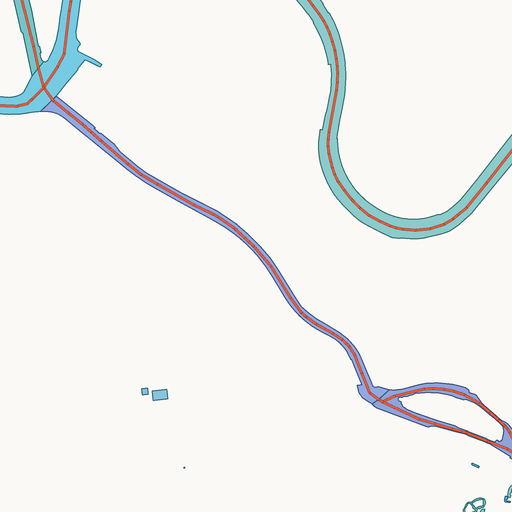

In [7]:
let png = render_water_geometries(&tile, DEFAULT_IMAGE_SIZE, 3).unwrap();
display_png(&png);
